# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
artificial intelligence is transforming industries by enabling machines to learn from data and make intelligent decisions
machine learning algorithms analyze patterns to solve real world problems efficiently
deep learning models use multiple neural network layers to capture complex relationships in large datasets
recurrent neural networks process sequential information by remembering previous inputs while predicting future outputs
long short term memory networks overcome the vanishing gradient problem using memory cells and gating mechanisms
gated recurrent units simplify recurrent learning while maintaining strong performance on sequence prediction tasks
natural language processing allows computers to understand generate and analyze human language effectively
text generation models learn grammar vocabulary and contextual relationships from training data to produce meaningful sentences
continuous experimentation with different neural network architectures helps improve model accuracy robustness and generalization
artificial intelligence continues to evolve rapidly and creates innovative solutions for healthcare education finance transportation and scientific research
'''
print(corpus)


artificial intelligence is transforming industries by enabling machines to learn from data and make intelligent decisions
machine learning algorithms analyze patterns to solve real world problems efficiently
deep learning models use multiple neural network layers to capture complex relationships in large datasets
recurrent neural networks process sequential information by remembering previous inputs while predicting future outputs
long short term memory networks overcome the vanishing gradient problem using memory cells and gating mechanisms
gated recurrent units simplify recurrent learning while maintaining strong performance on sequence prediction tasks
natural language processing allows computers to understand generate and analyze human language effectively
text generation models learn grammar vocabulary and contextual relationships from training data to produce meaningful sentences
continuous experimentation with different neural network architectures helps improve model accuracy 

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 117
X shape: (137, 17)
y shape: (137,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [8]:
EMBED_DIM = 64
HIDDEN_UNITS = 128
EPOCHS = 200

def build_model(rnn_layer):

    model = Sequential([
        Embedding(total_words, EMBED_DIM),
        rnn_layer(HIDDEN_UNITS),
        Dense(total_words, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [9]:
rnn_model = build_model(SimpleRNN)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=EPOCHS,
    verbose=0
)

print(
    f"Vanilla RNN done – final loss {rnn_history.history['loss'][-1]:.4f}, "
    f"acc {rnn_history.history['accuracy'][-1]:.4f}"
)

Vanilla RNN done – final loss 0.0224, acc 0.9927


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [10]:
lstm_model = build_model(LSTM)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=EPOCHS,
    verbose=0
)

print(
    f"LSTM done – final loss {lstm_history.history['loss'][-1]:.4f}, "
    f"acc {lstm_history.history['accuracy'][-1]:.4f}"
)

LSTM done – final loss 0.1173, acc 0.9927


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [11]:
gru_model = build_model(GRU)
gru_history = gru_model.fit(
    X,
    y,
    epochs=EPOCHS,
    verbose=0
)
print(
    f"GRU done – final loss {gru_history.history['loss'][-1]:.4f}, "
    f"acc {gru_history.history['accuracy'][-1]:.4f}"
)

GRU done – final loss 0.0296, acc 0.9927


## 📉 Compare Training Loss

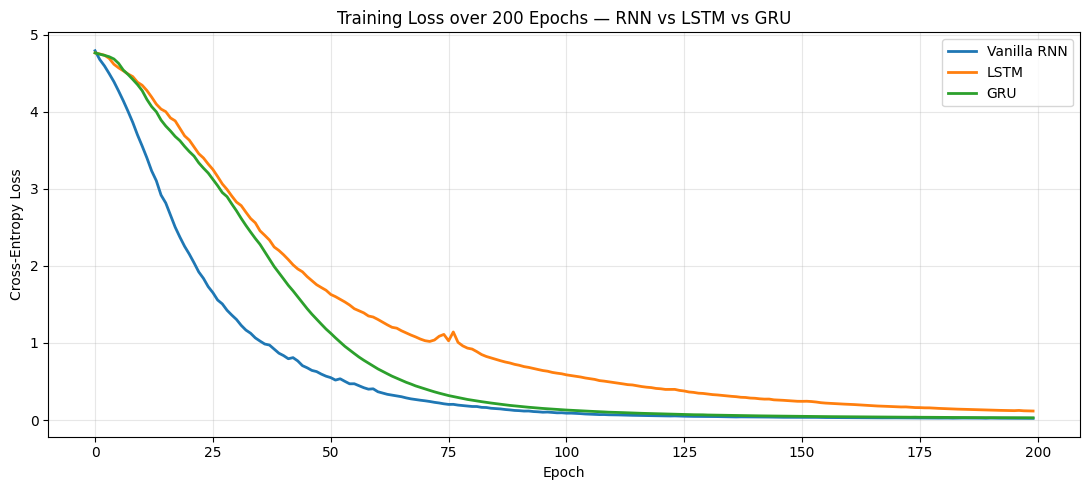

Final training loss:
 RNN  : 0.0224
 LSTM : 0.1173
 GRU  : 0.0296


In [12]:
plt.figure(figsize=(11,5))
plt.plot(
    rnn_history.history["loss"],
    label="Vanilla RNN",
    lw=2
)
plt.plot(
    lstm_history.history["loss"],
    label="LSTM",
    lw=2
)
plt.plot(
    gru_history.history["loss"],
    label="GRU",
    lw=2
)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Training Loss over {EPOCHS} Epochs — RNN vs LSTM vs GRU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Final training loss:")

for name, h in [
    ("RNN", rnn_history),
    ("LSTM", lstm_history),
    ("GRU", gru_history)
]:
    print(f" {name:<5}: {h.history['loss'][-1]:.4f}")

**Reading the Curves** - All three models achieve very low training loss because the custom corpus is small and easy to learn.
The Simple RNN may converge as quickly as or even faster than the LSTM and GRU on such a small dataset because it has fewer parameters.
This does **not** imply that the Simple RNN is a better architecture. On larger and more complex text datasets, LSTM and GRU generally perform better because they capture long-term dependencies more effectively.

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [13]:
def generate_text(model, seed_text, next_words=10):
    """
    Generate text using greedy argmax decoding.
    """
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences(
            [token_list],
            maxlen=max_len - 1,
            padding="pre"
        )
        probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(probs, axis=-1)[0]
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [14]:
seed_phrases = [
    "artificial intelligence",
    "deep learning",
    "machine learning"
]
for seed in seed_phrases:
    print(f"Seed: '{seed}'")
    print("  RNN :", generate_text(rnn_model, seed, 10))
    print("  LSTM:", generate_text(lstm_model, seed, 10))
    print("  GRU :", generate_text(gru_model, seed, 10))
    print()

Seed: 'artificial intelligence'
  RNN : artificial intelligence is transforming industries by enabling machines to learn from data
  LSTM: artificial intelligence continues to evolve rapidly and creates innovative solutions for healthcare
  GRU : artificial intelligence continues to evolve rapidly and creates innovative solutions for healthcare

Seed: 'deep learning'
  RNN : deep learning models use multiple neural network layers to capture complex relationships
  LSTM: deep learning models use multiple neural network layers to capture complex relationships
  GRU : deep learning models use multiple neural network layers to capture complex relationships

Seed: 'machine learning'
  RNN : machine learning algorithms analyze patterns to solve real world problems efficiently on
  LSTM: machine learning algorithms analyze patterns to solve real world problems efficiently efficiently
  GRU : machine learning algorithms analyze patterns to solve real world problems efficiently efficiently



**Generated Text Analysis** - The generated samples show that each architecture learns slightly different next-word probability distributions, even though all models are trained on the same corpus.

The **Vanilla RNN** generally learns short sequential patterns but may lose context over longer generations.
The **LSTM** maintains contextual information using memory cells and gating mechanisms, often producing more coherent sentences.
The **GRU** performs similarly to the LSTM while using a simpler architecture with fewer gates.

Because **greedy argmax decoding** always selects the highest-probability word, generated text can occasionally become repetitive. Modern language models often address this limitation using **temperature sampling**, **top-k sampling**, or **top-p (nucleus) sampling**, which introduce controlled randomness during generation.

# 9. Student Tasks — Summary

| # | Task | What Changed | Where |
|---|------|--------------|-------|
| 1 | Replace corpus | Default sample → Custom AI & Deep Learning corpus | Section 1 |
| 2 | Increase embedding dimension | **32 → 64** | Model Configuration |
| 3 | Increase epochs | **100 → 200** | Model Configuration |
| 4 | Increase hidden units | **64 → 128** | Model Configuration |
| 5 | Generate 10 words | Default **5 → 10** | `generate_text()` |

---

# Conclusion

- **Vanilla RNN** learns short sequence patterns efficiently but is susceptible to vanishing gradients on longer sequences.

- **LSTM** uses memory cells and gating mechanisms to retain long-term contextual information, producing more consistent text generation.

- **GRU** provides performance comparable to LSTM with a simpler architecture and faster training.

- **Greedy argmax decoding** produces deterministic outputs and may occasionally repeat words. More advanced decoding methods such as **temperature sampling**, **top-k**, and **top-p sampling** are commonly used to generate more diverse text.

- Because the training corpus is intentionally small, all three models achieve high training accuracy by effectively learning the available patterns. This notebook demonstrates the practical differences between **Vanilla RNN**, **LSTM**, and **GRU** for text generation.